# 05 · 端到端案例：从游戏截图到出价决策

**目的**：把 `scripts/demo_scenarios.py` 的三个场景做成可视化 notebook，作为项目交付物长期保留。每个场景演示：

1. **输入摘要**——一一对照 Streamlit UI 应该怎么填
2. **联合推断 top-3 候选**——引擎反推每个品质 bucket 的 `(总格数, 件数)`
3. **MC 价值分布**——条件采样 + p25/p50/p75 分位 + 直方图
4. **秒仓 / 放仓推荐**——gate 触发时输出价格区间；样本不足走低置信兜底

**为何不直接跑 `python scripts/demo_scenarios.py`**：notebook 留下可视化的 distribution 图、便于 reviewer 一眼看到"中位 + 离散"两件事。脚本是终端输出，可读性差。

**对照运行**：把同样的输入填进 Streamlit UI（`streamlit run app/streamlit_app.py`）应得到 ±MC 噪声的同结果。

## 1. 准备

加载三张原表（BidMap / Drop / Item）+ 推断引擎模块。matplotlib 用英文标签避免中文字体回退方块。

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

from bidking_lab.extract.bid_map_table import load_bid_map_table
from bidking_lab.extract.drop_table import load_drop_table
from bidking_lab.extract.item_table import load_item_table
from bidking_lab.inference.display import parse_reading
from bidking_lab.inference.ground_truth import sample_session_truth
from bidking_lab.inference.joint import joint_top_k_for_session
from bidking_lab.inference.observation import QualityBucketObs, SessionObs
from bidking_lab.inference.snipe import (
    compute_pass_recommendation,
    compute_snipe_recommendation,
)

TABLES = REPO / "data" / "raw" / "tables"
maps = load_bid_map_table(TABLES / "BidMap.txt")
drops = load_drop_table(TABLES / "Drop.txt")
items = load_item_table(TABLES / "Item.txt")
print(f"loaded {len(maps)} maps, {len(drops)} drop pools, {len(items)} items")

loaded 105 maps, 608 drop pools, 1132 items


In [2]:
QLABEL = {1: "白", 2: "绿", 3: "蓝", 4: "紫", 5: "金", 6: "红"}

def show_top_k(session: SessionObs, k: int = 3) -> None:
    hyps = joint_top_k_for_session(session, k=k, per_bucket_top=10)
    if not hyps:
        print("  (no joint candidate — over-constrained inputs)")
        return
    for i, h in enumerate(hyps, 1):
        per = "  ".join(
            f"q={q} {h.per_bucket[q].total_cells}\u683c/{h.per_bucket[q].count}\u4ef6"
            for q in sorted(h.per_bucket)
        )
        print(
            f"  #{i}  composite={h.composite:.3f}  total={h.total_cells}\u683c  "
            f"penalty={h.warehouse_penalty:.2f}  | {per}"
        )

def run_mc_and_plot(session: SessionObs, *, n_trials: int = 1500, seed: int = 20260515,
                     warehouse_tol: int = 8, title: str = "") -> dict:
    """Sample, condition on warehouse-cells match, plot distribution, return percentiles."""
    rng = np.random.default_rng(seed)
    truths = [
        sample_session_truth(session.map_id, maps=maps, drops=drops,
                              items=items, rng=rng)
        for _ in range(n_trials)
    ]
    wh = session.warehouse_total_cells
    matched = np.array(
        [t.total_value() for t in truths
         if abs(t.warehouse_total_cells - wh) <= warehouse_tol],
        dtype=np.int64,
    )
    all_vals = np.array([t.total_value() for t in truths], dtype=np.int64)
    if len(matched) < 5:
        print(f"  matched only {len(matched)}/{n_trials} — sample too thin")
        return {"truths": truths, "matched": matched}
    p25, p50, p75, p90 = (int(np.percentile(matched, q)) for q in (25, 50, 75, 90))
    print(
        f"  matched {len(matched)}/{n_trials}  "
        f"P25={p25:,}  P50={p50:,}  P75={p75:,}  P90={p90:,}"
    )
    fig, ax = plt.subplots(figsize=(7.5, 3.5))
    ax.hist(all_vals / 1e3, bins=40, color="#cccccc", alpha=0.55,
             label=f"All MC samples (n={n_trials})")
    ax.hist(matched / 1e3, bins=40, color="#1f77b4", alpha=0.85,
             label=f"Matched warehouse {wh}\u00b1{warehouse_tol} (n={len(matched)})")
    for q, v, color in [("P25", p25, "#d62728"), ("P50", p50, "#2ca02c"),
                          ("P75", p75, "#ff7f0e")]:
        ax.axvline(v / 1e3, linestyle="--", color=color, linewidth=1.2,
                    label=f"{q} = {v:,}")
    ax.set_xlabel("Session value (thousand silver)")
    ax.set_ylabel("frequency")
    ax.set_title(title or f"Map {session.map_id} value distribution (conditional)")
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()
    return {
        "truths": truths, "matched": matched,
        "p25": p25, "p50": p50, "p75": p75, "p90": p90,
    }

def show_snipe_pass(session: SessionObs, truths: list) -> None:
    snipe = compute_snipe_recommendation(
        session, maps=maps, drops=drops, items=items, truths=truths,
    )
    if snipe is None:
        print("  \U0001F3AF snipe : (gate not triggered)")
    else:
        tag = "  \u26A0\ufe0f LOW-CONF" if snipe.low_confidence else ""
        print(
            f"  \U0001F3AF snipe : floor {snipe.safe_floor_bid:,} \u2192 ceiling "
            f"{snipe.snipe_max_bid:,}  (P50={snipe.expected_value:,}, samples="
            f"{snipe.n_matching_samples}){tag}"
        )
    pass_rec = compute_pass_recommendation(
        session, maps=maps, drops=drops, items=items, truths=truths,
    )
    if pass_rec is None:
        print("  \U0001F6D1 pass  : (gate not triggered)")
    else:
        tag = "  \u26A0\ufe0f LOW-CONF" if pass_rec.low_confidence else ""
        print(
            f"  \U0001F6D1 pass  : pass above {pass_rec.pass_max_bid:,}  "
            f"(this cabinet \u2248 {pass_rec.value_ratio:.0%} of overall median){tag}"
        )

## 2. 场景 A · 伊森 · 沉船大仓 · 优品均格 2.90 尾零泄露 + 1 红巨物

**情境**：伊森在沉船 2510 跑到第 2 轮，手上配 普品扫描 + 良品扫描 + 优品均格 + 至宝寻踪。

| 道具 | 读数 | 含义 |
|---|---|---|
| 普品扫描 | 白+绿总格 22 | q=1 锁死 22 格 |
| 良品扫描 | 蓝总格 20 | q=3 锁死 20 格 |
| **优品均格** | **2.90**（尾零） | 紫品 cells/count 不是精确 2.9，**真值在 [2.90, 2.91)** → 候选只能是 32/11、35/12 等 |
| 至宝寻踪 | 1 个红巨物 | q=6 huge_band="1" |

**关键演示点**：均格 "2.90" vs "2.9" 的区别——尾零暗示分母**不整除 10**，引擎能据此挑出真实候选。

In [3]:
session_A = SessionObs(
    hero="ethan",
    map_id=2510,
    warehouse_total_cells=145,
    buckets={
        1: QualityBucketObs(quality=1, total_cells=22),
        3: QualityBucketObs(quality=3, total_cells=20),
        4: QualityBucketObs(quality=4, avg_cells=parse_reading("2.90")),
        6: QualityBucketObs(quality=6, huge_band="1"),
    },
)
print("[\u573a\u666f A]  \u6c89\u8239 2510  \u00b7  \u4f0a\u68ee  \u00b7  \u4ed3\u5e93 145 \u683c")
print("  inputs: q=1 cells=22  q=3 cells=20  q=4 avg=2.90(\u5c3e\u96f6)  q=6 huge=1")
print("\n\u8054\u5408\u63a8\u65ad top-3:")
show_top_k(session_A)

[场景 A]  沉船 2510  ·  伊森  ·  仓库 145 格
  inputs: q=1 cells=22  q=3 cells=20  q=4 avg=2.90(尾零)  q=6 huge=1

联合推断 top-3:
  #1  composite=0.014  total=90格  penalty=0.00  | q=1 22格/1件  q=3 20格/1件  q=4 32格/11件  q=6 16格/1件
  #2  composite=0.014  total=91格  penalty=0.00  | q=1 22格/1件  q=3 20格/1件  q=4 32格/11件  q=6 17格/1件
  #3  composite=0.014  total=92格  penalty=0.00  | q=1 22格/1件  q=3 20格/1件  q=4 32格/11件  q=6 18格/1件



MC 价值分布 (n_trials=3000, warehouse ±8):


  matched 29/3000  P25=891,154  P50=1,086,380  P75=1,531,571  P90=1,885,054


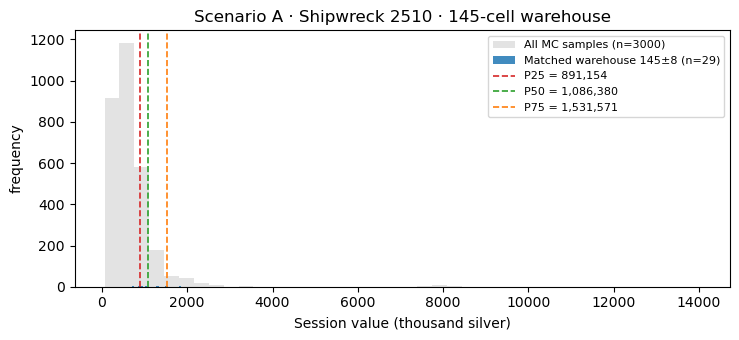


出价推荐:
  🎯 snipe : floor 760,466 → ceiling 1,761,306  (P50=1,086,380, samples=29)  ⚠️ LOW-CONF
  🛑 pass  : (gate not triggered)


In [4]:
print("\nMC \u4ef7\u503c\u5206\u5e03 (n_trials=3000, warehouse \u00b18):")
result_A = run_mc_and_plot(session_A, n_trials=3000, seed=20260515,
                             warehouse_tol=8,
                             title="Scenario A · Shipwreck 2510 · 145-cell warehouse")
print("\n\u51fa\u4ef7\u63a8\u8350:")
show_snipe_pass(session_A, result_A["truths"])

**读图**：橙色 P75 是秒仓 ceiling 的参考点；绿色 P50 是中位预期。匹配样本数偏少时（沉船 145 格在分布尾部）秒仓 gate 走的是新加的**低置信兜底**（`⚠️ LOW-CONF`）——保留了价格区间但显式提醒"采样不稳"，比之前的静默 None 更友好。

## 3. 场景 B · 伊森 · 沉船中小仓 · 紫均格整数 4 + 无巨物

**情境**：仓库估 95 格、白绿格数大、蓝紫一般、无任何巨物。紫品均格 = **4**（整数，无尾零 → 精确等于 4，意味着 total_cells / count = 4 整除）。

**关键演示点**：整数均格 + 小仓 + 无巨物 → MC 条件分布会显著低于全图均值，**放仓 gate 该触发**。这是 "junky cabinet" 的典型 signature，避免玩家盲目跟价被对手套出。

In [5]:
session_B = SessionObs(
    hero="ethan",
    map_id=2510,
    warehouse_total_cells=95,
    buckets={
        1: QualityBucketObs(quality=1, total_cells=28),
        3: QualityBucketObs(quality=3, total_cells=14),
        4: QualityBucketObs(quality=4, avg_cells=parse_reading("4"), total_cells=12),
        5: QualityBucketObs(quality=5, huge_band="none"),
        6: QualityBucketObs(quality=6, huge_band="none"),
    },
)
print("[\u573a\u666f B]  \u6c89\u8239 2510  \u00b7  \u4f0a\u68ee  \u00b7  \u4ed3\u5e93 95 \u683c (\u4e2d\u5c0f\u4ed3)")
print("  inputs: q=1 cells=28  q=3 cells=14  q=4 cells=12 avg=4(\u6574\u6570)  \u91d1\u7ea2\u65e0\u5de8\u7269")
print("\n\u8054\u5408\u63a8\u65ad top-3:")
show_top_k(session_B)

[场景 B]  沉船 2510  ·  伊森  ·  仓库 95 格 (中小仓)
  inputs: q=1 cells=28  q=3 cells=14  q=4 cells=12 avg=4(整数)  金红无巨物

联合推断 top-3:
  #1  composite=0.007  total=56格  penalty=0.00  | q=1 28格/1件  q=3 14格/1件  q=4 12格/3件  q=5 1格/1件  q=6 1格/1件
  #2  composite=0.007  total=57格  penalty=0.00  | q=1 28格/1件  q=3 14格/1件  q=4 12格/3件  q=5 2格/1件  q=6 1格/1件
  #3  composite=0.007  total=58格  penalty=0.00  | q=1 28格/1件  q=3 14格/1件  q=4 12格/3件  q=5 3格/1件  q=6 1格/1件



MC 价值分布 (n_trials=1500, warehouse ±8):


  matched 381/1500  P25=482,165  P50=647,626  P75=887,614  P90=1,269,929


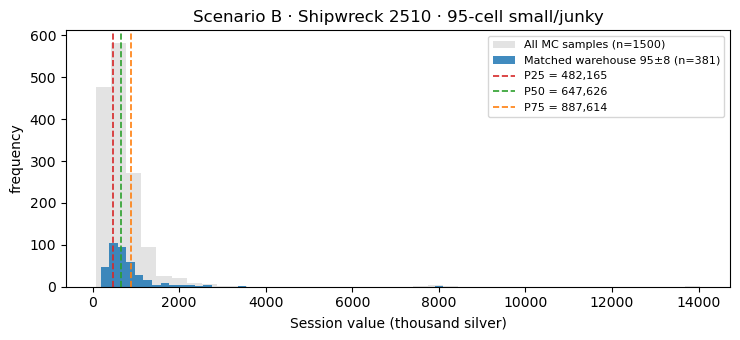


出价推荐:
  🎯 snipe : (gate not triggered)
  🛑 pass  : (gate not triggered)


In [6]:
print("\nMC \u4ef7\u503c\u5206\u5e03 (n_trials=1500, warehouse \u00b18):")
result_B = run_mc_and_plot(session_B, n_trials=1500, seed=20260515,
                             warehouse_tol=8,
                             title="Scenario B · Shipwreck 2510 · 95-cell small/junky")
print("\n\u51fa\u4ef7\u63a8\u8350:")
show_snipe_pass(session_B, result_B["truths"])

**读图**：条件分布（蓝）整体向左偏，相比全图（灰）显著缩水——"放仓" gate 该触发，告诉玩家 "超过 P50 就放"。若没触发也是合理结果（低品占比未达 40% 或样本不足，gate 故意保守）。

## 4. 场景 C · 艾莎 · 别墅大仓 · R1-R4 轮廓全开 + 优品估价 + 紫巨物 2-3

**情境**：艾莎挂机到 R4，4 级渐进轮廓让她免费拿到 白/绿/蓝/紫 的（总格数, 件数）；R4 又花一个优品估价拿到紫品总价 89,400；R4 也能看到紫品巨物 2-3 个。地图还提示"35 件藏品"（部分别墅 R1 hint）。

**关键演示点**：所有低品 bucket 被 (cells × count × value × huge_band) 多重锁死 → 联合推断 top-3 应该收敛到 1-2 个候选。这是"信息密度最高"的玩家情境。

In [7]:
session_C = SessionObs(
    hero="aisha",
    map_id=2407,
    warehouse_total_cells=128,
    total_item_count=35,
    buckets={
        1: QualityBucketObs(quality=1, total_cells=24, count=12),
        2: QualityBucketObs(quality=2, total_cells=18, count=7),
        3: QualityBucketObs(quality=3, total_cells=22, count=5),
        4: QualityBucketObs(
            quality=4, total_cells=48, count=8,
            value_sum=89400, huge_band="2-3",
        ),
    },
)
print("[\u573a\u666f C]  \u522b\u5885 2407  \u00b7  \u827e\u838e  \u00b7  \u4ed3\u5e93 128 \u683c")
print("  inputs: \u8f6e\u5ed3 R1-R4 cells+count \u5168\u9501  q=4 value=89,400  q=4 huge=2-3")
print("\n\u8054\u5408\u63a8\u65ad top-3:")
show_top_k(session_C)

[场景 C]  别墅 2407  ·  艾莎  ·  仓库 128 格
  inputs: 轮廓 R1-R4 cells+count 全锁  q=4 value=89,400  q=4 huge=2-3

联合推断 top-3:
  #1  composite=0.342  total=112格  penalty=0.06  | q=1 24格/12件  q=2 18格/7件  q=3 22格/5件  q=4 48格/8件



MC 价值分布 (n_trials=1500, warehouse ±8):


  matched 16/1500  P25=623,841  P50=866,252  P75=1,199,555  P90=1,867,729


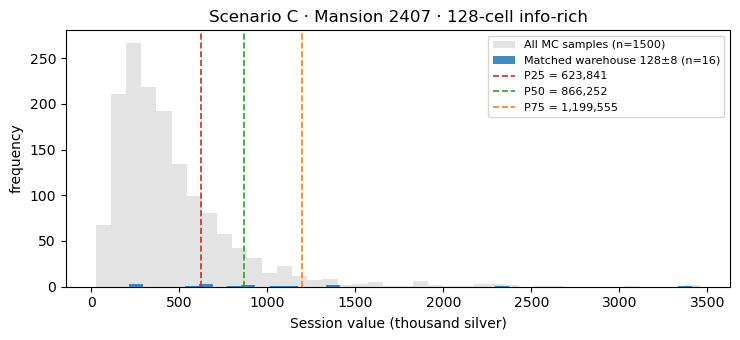


出价推荐:
  🎯 snipe : floor 606,376 → ceiling 1,379,488  (P50=866,252, samples=16)  ⚠️ LOW-CONF
  🛑 pass  : (gate not triggered)


In [8]:
print("\nMC \u4ef7\u503c\u5206\u5e03 (n_trials=1500, warehouse \u00b18):")
result_C = run_mc_and_plot(session_C, n_trials=1500, seed=20260515,
                             warehouse_tol=8,
                             title="Scenario C · Mansion 2407 · 128-cell info-rich")
print("\n\u51fa\u4ef7\u63a8\u8350:")
show_snipe_pass(session_C, result_C["truths"])

**读图**：信息密度最高的场景，top-1 应该几乎吃掉所有 composite mass（其他候选 composite 差距明显）。MC 分布相比场景 A 也更紧凑——因为多 bucket 的硬约束已经把世界压缩到很窄的几何空间。

---

## 总结

三场景覆盖了项目的三大核心信息源：

| 场景 | 玩家信息源 | 引擎发挥处 |
|---|---|---|
| **A** | 道具读数 + 小数尾零 + 巨物 | 截断显示规则 → 锁死 q=4 (cells, count) 候选 |
| **B** | 道具读数 + 整数均格 + 无巨物 | 全 bucket 多重约束 + "放仓 gate" 提示小仓低价 |
| **C** | 英雄轮廓（0 silver）+ 1 道具 + 地图 hint | 联合推断 + 件数总数交叉约束 → 候选近 unique |

把同样输入填进 Streamlit UI 应得到 ±MC 随机噪声的一致结果——这就是引擎与 UI 一致性的端到端验证。